In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split

In [9]:
class KNN:
    def euclidean(self, x_1, x_2):
        dist = np.sqrt(np.sum((x_1 - x_2)**2))
        return dist
    def __init__(self,k=3):
        self.k = k

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.y_train = np.array(Y)
    def predict(self, X):
        X = np.array(X)
        predicted_labels = [self._predict(x) for x in X]
        return np.array(predicted_labels)

    def _predict(self, x):
        distance = [self.euclidean(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distance)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_com = Counter(k_nearest_labels).most_common(1)
        return most_com[0][0]
def lbl_encode(y):
        label = list(set(y))
        maps = {lbl:i for i,lbl in enumerate(label)}
        return np.array([maps[j] for j in y])
def standard( x):
        mean = np.mean(x, axis=0)
        st = np.std(x, axis=0)
        return (x - mean) / st

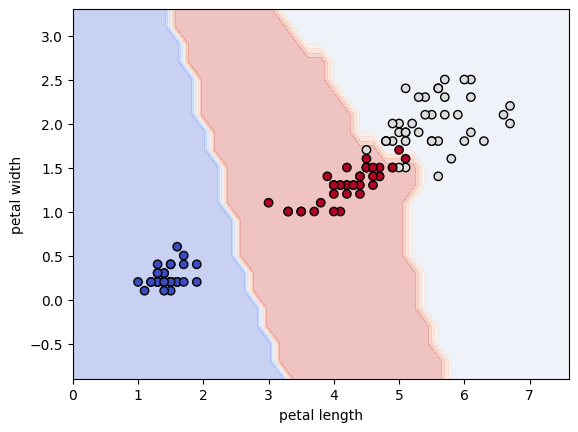

In [14]:
data_frame = pd.read_csv('iris.csv')


X = data_frame[['petal.length', 'petal.width']]
y = data_frame['variety']


y = lbl_encode(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
knn = KNN(k = 5)
knn.fit(X_train, y_train)
min_x = X_train.iloc[:,0].min() - 1
min_y = X_train.iloc[:,1].min() - 1

max_x = X_train.iloc[:,0].max() + 1
max_y = X_train.iloc[:,1].max() + 1


x2, y2 = np.meshgrid(
    np.arange(min_x, max_x, 0.2),
    np.arange(min_y, max_y, 0.2)
)

grid = np.c_[x2.ravel(), y2.ravel()]

pred = knn.predict(grid)
pred = pred.reshape(x2.shape)

plt.contourf(x2, y2, pred, alpha=0.3, cmap='coolwarm')

plt.scatter(
    X_train.iloc[:,0],
    X_train.iloc[:,1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k'
)

plt.xlabel("petal length")
plt.ylabel("petal width")
plt.show()